# E04 · Changepoints and discrete latent variables

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | Jarrett (1979): dates of 191 UK coal-mining disasters, 1851-1962 |
| **You will learn** | Poisson rates for event counts · a changepoint model · why NUTS cannot sample a discrete parameter and what PyMC does instead · **marginalising** a discrete latent out by hand (`logsumexp` + `pm.Potential`) and automatically (`pymc_extras.marginal`) · recovering its posterior afterwards · LOO when a discrete latent is involved · comparing an abrupt change with smooth alternatives |

NUTS needs gradients, and a parameter that can only be 1887 or 1888 does not have one.
Discrete latent variables - changepoints, mixture memberships, hidden states - are
therefore the classic place where PyMC models that *run* quietly stop being models that
run *well*. The standard cure is to sum the discrete variable out of the likelihood, sample
the continuous parameters with NUTS, and reconstruct the discrete posterior afterwards.
This notebook does that on the oldest changepoint dataset in the book.

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from pymc_extras.marginal import marginalize, recover
from scipy import stats
from scipy.special import logsumexp, softmax

from pymc_challenges import data

# PyMC's default backend warns that it falls back to slower code for DiscreteUniform draws. Harmless here.
warnings.filterwarnings("ignore", message="Numba will use object mode")

RANDOM_SEED = 1887
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

## 1 · Question and data

*Did British coal mining become safer at some point in the 19th century - and if so, when,
and by how much?*

The file holds one row per disaster (an explosion that killed ten or more miners), with its
date as a decimal year.

In [2]:
data.describe("coal")
coal = data.load("coal")
print(coal.shape, "- first", coal.date.min().round(2), "last", coal.date.max().round(2))
coal.head()

coal: Dates (decimal years) of 191 explosions that killed 10 or more miners.
  source: Jarrett (1979), UK coal-mining disasters 1851-1962, via R package `boot`.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/boot/coal.csv
(191, 1) - first 1851.2 last 1962.22


,date
rownames,
1,1851.202601
2,1851.632444
3,1851.969199
4,1851.974675
5,1852.314168


Event dates are not yet something a Poisson likelihood can use. We aggregate to **counts
per calendar year**. The step that is easy to get wrong: years with *no* disaster do not
appear in the file at all, and they are data too. `reindex(..., fill_value=0)` puts them back.

In [3]:
years = np.arange(1851, 1963)
disasters = (
    np.floor(coal.date).astype(int).value_counts().reindex(years, fill_value=0).rename("disasters")
)
disasters.index.name = "year"
y = disasters.values
T = len(years)

print(f"{T} years, {y.sum()} disasters, {(y == 0).sum()} years with none")
print(f"mean {y.mean():.2f} per year, variance {y.var():.2f}")

112 years, 191 disasters, 33 years with none
mean 1.71 per year, variance 2.67


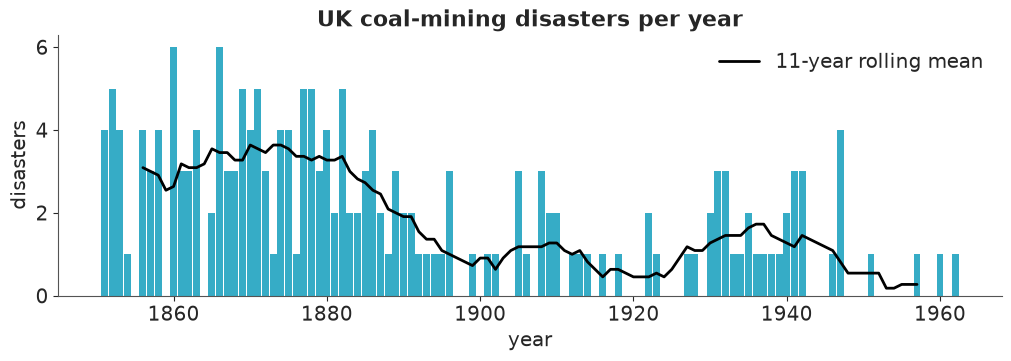

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(years, y, color="C0", width=0.9)
ax.plot(years, disasters.rolling(11, center=True).mean(), color="k", lw=2, label="11-year rolling mean")
ax.set(xlabel="year", ylabel="disasters", title="UK coal-mining disasters per year")
ax.legend();

Around three a year until the 1880s, around one a year afterwards. (The first and last
calendar years are only partly covered; we ignore that.) A rolling mean smears any change
over its window, so it cannot tell us whether the drop was sudden or gradual. A model can.

## 2 · The baseline: one constant rate

Counts of rare, independent events in a fixed interval are Poisson. Start with a single
rate $\lambda$. For the prior: disasters on this scale are a-few-a-year events, not
dozens-a-year events. `Exponential(0.5)` has mean 2 and puts 99% of its mass below 9.2.

In [5]:
with pm.Model(coords={"year": years}) as constant_model:
    rate = pm.Exponential("rate", 0.5)
    pm.Poisson("disasters", rate, observed=y, dims="year")
    constant_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    pm.sample_posterior_predictive(
        constant_idata, extend_inferencedata=True, random_seed=RANDOM_SEED, progressbar=False
    )

az.summary(constant_idata, round_to=2)

NUTS[nutpie]: [rate]


Sampling: [disasters]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
rate,1.7,0.12,1.51,1.9,1636.52,2062.65,1.0,0.0,0.0


A Poisson variable has variance equal to its mean. The data have mean 1.7 but variance 2.7,
so the variance is a natural test statistic for the posterior predictive check:

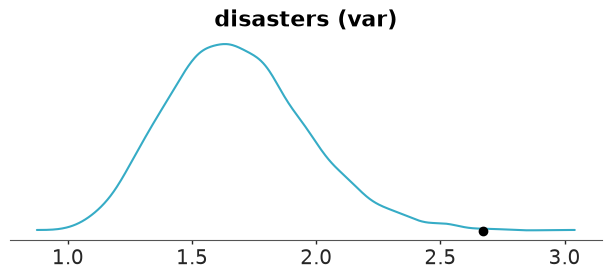

In [6]:
az.plot_ppc_tstat(constant_idata, t_stat="var");

The observed variance is far in the right tail of what a constant-rate model can generate.
Extra variance in counts means the rate is not constant. A Negative Binomial would absorb
the overdispersion, but it would not *explain* it: the plot above says the excess comes
from a rate that changes **over time**.

## 3 · The changepoint model

$$
\begin{aligned}
s &\sim \text{DiscreteUniform}(1851, 1962) \\
\lambda_\text{early},\ \lambda_\text{late} &\sim \text{Exponential}(0.5) \\
y_t &\sim \text{Poisson}(\lambda_\text{early}) \text{ if } t < s, \text{ else } \text{Poisson}(\lambda_\text{late})
\end{aligned}
$$

$s$ is the first year of the new regime. The uniform prior says "one change, and I have no
idea when". Written in PyMC exactly as in the maths:

In [7]:
with pm.Model(coords={"year": years}) as discrete_model:
    early_rate = pm.Exponential("early_rate", 0.5)
    late_rate = pm.Exponential("late_rate", 0.5)
    switchpoint = pm.DiscreteUniform("switchpoint", lower=years.min(), upper=years.max())
    rate = pm.math.switch(years < switchpoint, early_rate, late_rate)
    pm.Poisson("disasters", rate, observed=y, dims="year")

    discrete_prior = pm.sample_prior_predictive(200, random_seed=RANDOM_SEED)

Sampling: [disasters, early_rate, late_rate, switchpoint]


share of simulated yearly counts above 10: 0.014


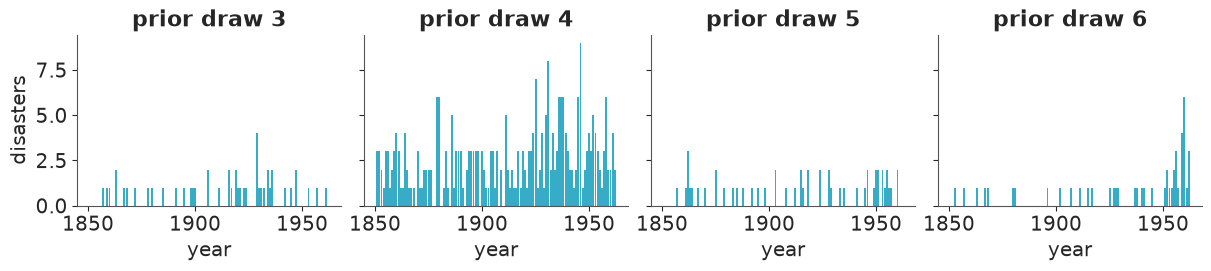

In [8]:
prior_y = discrete_prior.prior_predictive["disasters"].sel(chain=0)
fig, axes = plt.subplots(1, 4, figsize=(12, 2.6), sharey=True)
for ax, d in zip(axes, [3, 4, 5, 6]):
    ax.bar(years, prior_y.sel(draw=d), width=0.9)
    ax.set(xlabel="year", title=f"prior draw {d}")
axes[0].set_ylabel("disasters")
print("share of simulated yearly counts above 10:", float((prior_y > 10).mean().round(3)))

Prior simulations show a step somewhere, going up or down, with yearly counts on a believable
scale. Nothing here knows that mining got safer.

## 4 · Approach A: let PyMC pick a sampler for the discrete parameter

`pm.sample` does not refuse this model. It inspects every free variable and builds a
**compound step**: NUTS for the continuous rates, a Metropolis sampler for the integer
`switchpoint`, alternating between the two within each iteration.

In [9]:
with discrete_model:
    discrete_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

az.summary(discrete_idata, round_to=2)

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>NUTS: [early_rate, late_rate]


>Metropolis: [switchpoint]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
switchpoint,1891.00,2.42,1887.00,1895.00,469.42,548.06,1.01,0.11,0.08
early_rate,3.11,0.28,2.66,3.56,2181.37,2489.91,1.00,0.01,0.00
late_rate,0.93,0.12,0.75,1.12,2590.97,2426.33,1.00,0.00,0.00


Read the log lines above the table: `NUTS: [early_rate, late_rate]` and
`Metropolis: [switchpoint]`. No error, no warning, `r_hat` close to 1. Now compare the
`ess_bulk` column: the two rates have thousands of effective draws, `switchpoint` has a
few hundred out of the same 4000 iterations.

{'switchpoint': 469, 'early_rate': 2181, 'late_rate': 2590}
Metropolis acceptance rate for switchpoint: 0.51


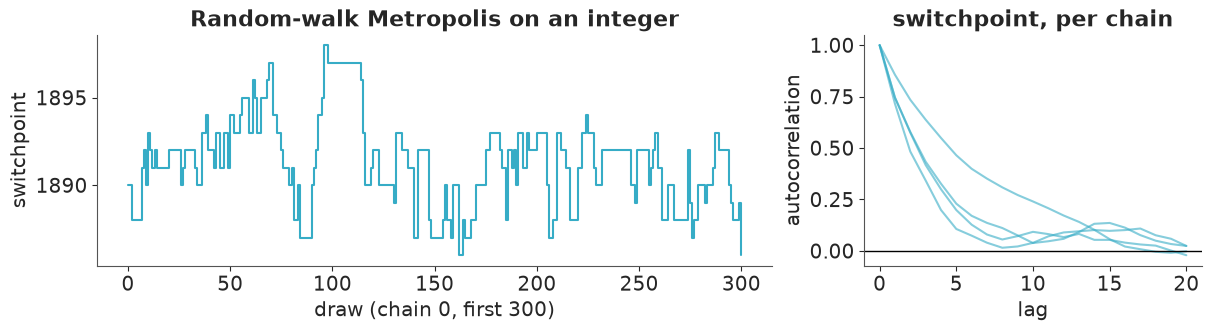

In [10]:
ess = az.ess(discrete_idata)
accept = float(discrete_idata.sample_stats["accepted"].mean())
print({k: int(v) for k, v in ess.data_vars.items()})
print(f"Metropolis acceptance rate for switchpoint: {accept:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2), width_ratios=[2, 1])
axes[0].plot(discrete_idata.posterior["switchpoint"].sel(chain=0, draw=slice(0, 300)), drawstyle="steps-post")
axes[0].set(xlabel="draw (chain 0, first 300)", ylabel="switchpoint", title="Random-walk Metropolis on an integer")
for c in discrete_idata.posterior.chain.values:
    draws = discrete_idata.posterior["switchpoint"].sel(chain=c).values
    acf = [1.0] + [np.corrcoef(draws[:-k], draws[k:])[0, 1] for k in range(1, 21)]
    axes[1].plot(acf, color="C0", alpha=0.6)
axes[1].axhline(0, color="k", lw=1)
axes[1].set(xlabel="lag", ylabel="autocorrelation", title="switchpoint, per chain");

The trace is a staircase: about half of the Metropolis proposals are rejected, the accepted
ones move a year or two, and so successive draws stay correlated for ten lags or more.

To be fair, this is the *easy* case - one discrete parameter, 112 possible values, a
posterior concentrated on a handful of them - and Metropolis gets a usable answer. The
reasons not to stop here:

- The number of effective draws for the quantity we care about most is several times
  lower than for everything else, and tail questions ("how likely is a change after 1895?")
  are answered by counting a handful of draws.
- It scales badly. Two changepoints, or one latent class per observation, and Metropolis
  moves one coordinate at a time through a space that grows combinatorially.
- NUTS's diagnostics (divergences, energy) say nothing about the Metropolis half. A stuck
  discrete sampler fails silently.

## 5 · Approach B: marginalise the switchpoint out

We do not need to *sample* $s$. It takes finitely many values, so we can sum over all of
them and obtain a likelihood that involves only the continuous parameters:

$$
p(y \mid \lambda_e, \lambda_l) = \sum_{k} p(s = k)\; \prod_{t < k} \text{Poisson}(y_t \mid \lambda_e) \prod_{t \ge k} \text{Poisson}(y_t \mid \lambda_l)
$$

On the log scale the sum becomes a `logsumexp`, and the two products become cumulative
sums, so all 112 candidate years cost two `cumsum` calls:

- `before[k]` = log-likelihood of years `0..k-1` under the early rate,
- `after[k]` = log-likelihood of years `k..T-1` under the late rate,
- `lp_switch[k] = log p(s=k) + before[k] + after[k]` is $\log p(y, s = k \mid \lambda)$.

`pm.Potential` adds an arbitrary term to the model's log-density - here the marginal
log-likelihood. There is no `observed=` anywhere: the data enter through `pm.logp`.

In [11]:
with pm.Model(coords={"year": years}) as marginal_model:
    early_rate = pm.Exponential("early_rate", 0.5)
    late_rate = pm.Exponential("late_rate", 0.5)

    ll_early = pm.logp(pm.Poisson.dist(early_rate), y)  # (T,) each year scored under the early rate
    ll_late = pm.logp(pm.Poisson.dist(late_rate), y)

    before = pt.concatenate([[0.0], pt.cumsum(ll_early)[:-1]])
    after = pt.cumsum(ll_late[::-1])[::-1]
    lp_switch = pm.Deterministic("lp_switch", before + after - np.log(T), dims="year")

    pm.Potential("marginal_loglike", pt.logsumexp(lp_switch))

    marginal_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

az.summary(marginal_idata, var_names=["early_rate", "late_rate"], round_to=2)

NUTS[nutpie]: [early_rate, late_rate]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
early_rate,3.11,0.29,2.67,3.58,4535.51,3110.96,1.0,0.0,0.0
late_rate,0.93,0.12,0.76,1.13,4310.55,3046.18,1.0,0.0,0.0


Pure NUTS, two parameters, same posterior for the rates as before, ESS in the thousands.

### Getting the switchpoint back

Marginalising did not throw $s$ away. By Bayes' rule, *given the rates*, the posterior of
the switchpoint is the normalised `lp_switch` vector:
$p(s = k \mid y, \lambda) = \text{softmax}(\texttt{lp\_switch})_k$. Averaging that over the
posterior draws of $\lambda$ gives $p(s = k \mid y)$. Every draw contributes a full
probability vector rather than a single year, so the estimate is far less noisy than
counting Metropolis draws (this trick is called Rao-Blackwellisation).

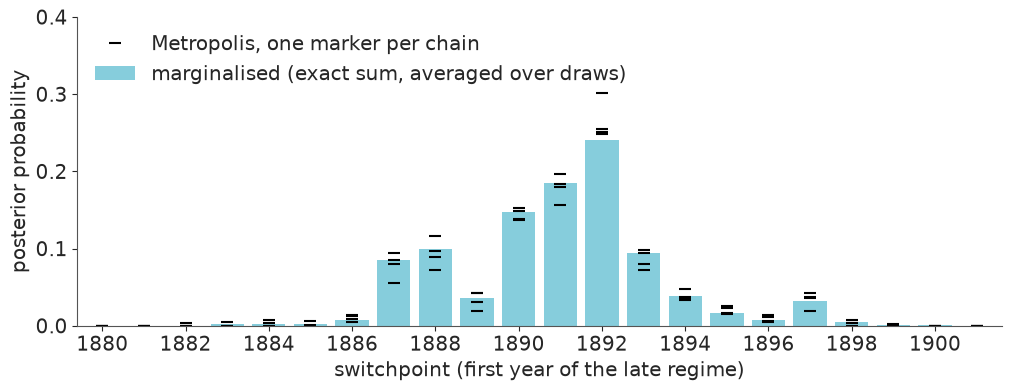

In [12]:
p_switch = softmax(marginal_idata.posterior["lp_switch"].values, axis=-1).mean(axis=(0, 1))
p_switch = pd.Series(p_switch, index=years)

metropolis_by_chain = np.stack([
    np.bincount(chain_draws - years.min(), minlength=T) / chain_draws.size
    for chain_draws in discrete_idata.posterior["switchpoint"].values
])

window = slice(1880, 1902)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(p_switch.loc[window].index, p_switch.loc[window], color="C0", alpha=0.6, label="marginalised (exact sum, averaged over draws)")
for i, chain_p in enumerate(metropolis_by_chain):
    ax.plot(years, chain_p, "_", color="k", ms=9, mew=1.5, label="Metropolis, one marker per chain" if i == 0 else None)
ax.set(xlim=(1879.4, 1901.6), ylim=(0, 0.4), xticks=np.arange(1880, 1902, 2),
       xlabel="switchpoint (first year of the late regime)", ylabel="posterior probability")
ax.legend(loc="upper left");

In [13]:
print("most probable years:")
print(p_switch.sort_values(ascending=False).head(6).round(3).to_string())
print(f"\nP(1887 <= s <= 1895) = {p_switch.loc[1887:1895].sum():.3f}")
print(f"P(s >= 1896)         = {p_switch.loc[1896:].sum():.3f}")
print("  same, Metropolis per chain:", metropolis_by_chain[:, years >= 1896].sum(axis=1).round(3))

most probable years:
1892    0.240
1891    0.185
1890    0.147
1888    0.100
1893    0.094
1887    0.086

P(1887 <= s <= 1895) = 0.942
P(s >= 1896)         = 0.045
  same, Metropolis per chain: [0.058 0.033 0.048 0.047]


The two approaches target the same distribution and agree on the shape. The posterior is
lumpy: a change can only be "seen" between a bad year and a good one, so years that follow
a cluster of disasters (1887-88, 1890-92, and a small bump at 1897) collect the mass. The
spread of the black markers is Monte Carlo error: four Metropolis chains of 1000 draws
each give visibly different heights for the same bar, and their answers for the small tail
probability $P(s \ge 1896)$ range from about 0.03 to 0.06.

### The same thing, automatically

Writing the `cumsum` version by hand is instructive once. `pymc_extras` can do the algebra
for you: `marginalize` rewrites the model from section 3 into one without `switchpoint`,
and `recover` samples the marginalised variable back, conditional on each posterior draw.

In [14]:
auto_model = marginalize(discrete_model, ["switchpoint"])

with auto_model:
    step_idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

recover(step_idata, model=auto_model, random_seed=RANDOM_SEED)
az.summary(step_idata, round_to=2)

NUTS[nutpie]: [early_rate, late_rate]


Sampling: [switchpoint]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
early_rate,3.11,0.29,2.67,3.58,4535.51,3110.96,1.0,0.00,0.00
late_rate,0.93,0.12,0.76,1.13,4310.55,3046.18,1.0,0.00,0.00
switchpoint,1890.92,2.39,1887.00,1894.00,4083.25,4028.76,1.0,0.04,0.03


The rows for the two rates are *identical* to the hand-written version: same density, same
seed, therefore the same draws - a reassuring check on our algebra. `switchpoint` is back
in the posterior group, now as independent draws given the rates - compare its `ess_bulk`
with the Metropolis version in section 4. (The automatic version evaluates the full
likelihood once per candidate value instead of using the cumulative-sum trick. Irrelevant
at this size; for long series the hand-written version is much cheaper. Older tutorials
call `recover` by its deprecated name `recover_marginals`.)

## 6 · Does the model reproduce the data?

With `switchpoint` recovered, `step_idata` holds everything the *original* model needs, so
we can use that model for posterior predictive sampling.

Sampling: [disasters]


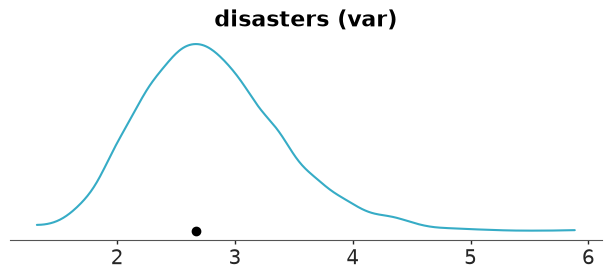

In [15]:
with discrete_model:
    pm.sample_posterior_predictive(step_idata, extend_inferencedata=True, random_seed=RANDOM_SEED, progressbar=False)

az.plot_ppc_tstat(step_idata, t_stat="var");

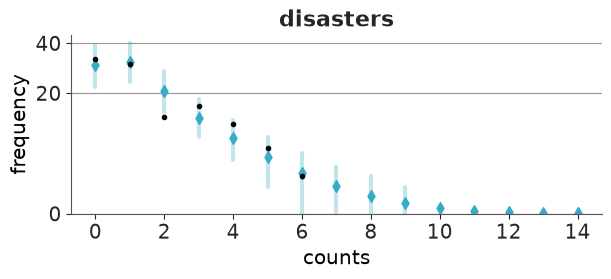

In [16]:
az.plot_ppc_rootogram(step_idata);

The observed variance now sits in the middle of the predictive distribution, and in the
rootogram (the frequency of each count value, on a square-root scale) the observed
frequencies fall within or at the edge of the predictive intervals, with no systematic
surplus of zeros or of large counts. Two Poisson rates and a date are enough to account for
the overdispersion that sank the constant model.

## 7 · Was it really a step? Two smooth alternatives

A changepoint model will find a changepoint in anything. Safety improvements are adopted
pit by pit, so a gradual decline is at least as plausible a priori. Two competitors:

**Sigmoid transition.** The log-rate slides from early to late along a logistic curve
centred at $\tau$ with time scale $w$ years (10% to 90% of the change takes about $4.4\,w$).
As $w \to 0$ this *is* the step model - and that limit is a region of extreme curvature, which
NUTS reports as divergences if the prior lets $w$ approach zero. Annual data cannot resolve
a transition faster than about a year anyway, so we use a `Gamma(2, 0.5)` prior (mean 4
years) that vanishes at zero. Both $\tau$ and $w$ are continuous: NUTS handles all of it.

In [17]:
with pm.Model(coords={"year": years}) as sigmoid_model:
    early_rate = pm.Exponential("early_rate", 0.5)
    late_rate = pm.Exponential("late_rate", 0.5)
    tau = pm.Uniform("tau", years.min(), years.max())
    width = pm.Gamma("width", 2, 0.5)

    weight = pm.math.sigmoid((years - tau) / width)
    log_rate = pm.Deterministic(
        "log_rate", (1 - weight) * pm.math.log(early_rate) + weight * pm.math.log(late_rate), dims="year"
    )
    pm.Poisson("disasters", pm.math.exp(log_rate), observed=y, dims="year")

    sigmoid_idata = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)

print("divergences:", int(sigmoid_idata.sample_stats["diverging"].sum()))
az.summary(sigmoid_idata, var_names=["early_rate", "late_rate", "tau", "width"], round_to=2)

NUTS[nutpie]: [early_rate, late_rate, tau, width]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
early_rate,3.27,0.34,2.77,3.83,3057.22,2628.74,1.0,0.01,0.01
late_rate,0.89,0.12,0.71,1.09,3135.20,3072.06,1.0,0.00,0.00
tau,1890.97,2.99,1886.51,1895.66,2622.00,2396.13,1.0,0.06,0.07
width,3.27,1.87,0.96,6.67,2233.07,1701.48,1.0,0.04,0.04


**Random walk.** No changepoint at all: the log-rate drifts from year to year,
$\log\lambda_t = \log\lambda_{t-1} + \sigma z_t$. Written non-centred - standard-normal
innovations `z`, scaled and cumulated - because one count per year says little about each
individual $\lambda_t$ - the situation in which the centred form (`pm.GaussianRandomWalk`)
suffers from the same funnel geometry as a centred hierarchical model. The `HalfNormal(0.2)`
prior on $\sigma$ allows the rate to change by up to roughly 20-40% in a year.

In [18]:
with pm.Model(coords={"year": years}) as rw_model:
    sigma = pm.HalfNormal("sigma", 0.2)
    log_rate_0 = pm.Normal("log_rate_0", 0, 1.5)
    z = pm.Normal("z", 0, 1, dims="year")
    log_rate = pm.Deterministic("log_rate", log_rate_0 + pt.cumsum(sigma * z), dims="year")
    pm.Poisson("disasters", pm.math.exp(log_rate), observed=y, dims="year")

    rw_idata = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False)

print("divergences:", int(rw_idata.sample_stats["diverging"].sum()))
rw_summary = az.summary(rw_idata, var_names=["sigma", "log_rate"], round_to=2)
print("worst r_hat:", rw_summary.r_hat.max(), " lowest ess_bulk:", int(rw_summary.ess_bulk.min()))
rw_summary.loc[["sigma"]]

NUTS[nutpie]: [sigma, log_rate_0, z]


divergences: 0


worst r_hat: 1.0  lowest ess_bulk: 1487


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma,0.15,0.05,0.08,0.23,1487.37,2045.96,1.0,0.0,0.0


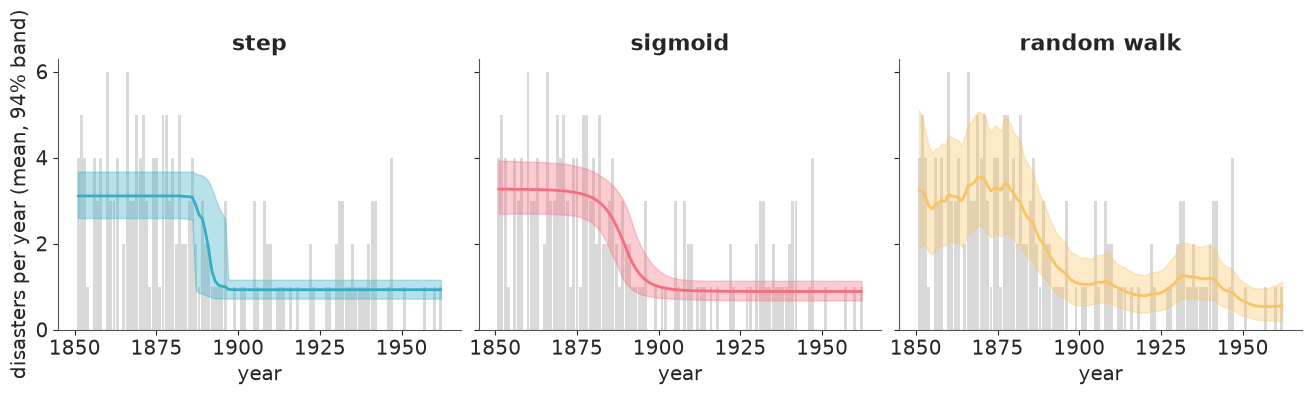

In [19]:
step_post = az.extract(step_idata, var_names=["early_rate", "late_rate", "switchpoint"])
step_rate = np.where(
    years[None, :] < step_post["switchpoint"].values[:, None],
    step_post["early_rate"].values[:, None],
    step_post["late_rate"].values[:, None],
)
rate_draws = {
    "step": step_rate,
    "sigmoid": np.exp(az.extract(sigmoid_idata, var_names="log_rate").transpose("sample", "year").values),
    "random walk": np.exp(az.extract(rw_idata, var_names="log_rate").transpose("sample", "year").values),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, (name, draws), color in zip(axes, rate_draws.items(), ["C0", "C1", "C2"]):
    lo, hi = np.quantile(draws, [0.03, 0.97], axis=0)
    ax.bar(years, y, color="k", alpha=0.15, width=0.9)
    ax.fill_between(years, lo, hi, color=color, alpha=0.35)
    ax.plot(years, draws.mean(axis=0), color=color, lw=2)
    ax.set(title=name, xlabel="year")
axes[0].set_ylabel("disasters per year (mean, 94% band)");

The step model's posterior *mean* rate is a ramp even though every single draw is a step:
averaging over the uncertain date rounds the corner. The sigmoid looks almost the same.
The random walk agrees on the two plateaus and on the timing of the decline, and adds
slow wiggles that the other two cannot express (a dip around 1920, a bump in the 1930s).

### LOO with a discrete latent

`pm.compute_log_likelihood` on the original model gives $\log p(y_t \mid \lambda, s)$ per
year, *conditional on each draw's switchpoint*:

In [20]:
with discrete_model:
    pm.compute_log_likelihood(step_idata, progressbar=False)

loo_conditional = az.loo(step_idata, pointwise=True)
print(loo_conditional)
bad = loo_conditional.pareto_k.where(loo_conditional.pareto_k > 0.7, drop=True)
print("\nyears with Pareto k > 0.7:", dict(zip(bad.year.values.tolist(), bad.values.round(2))))

Computed from 4000 posterior samples and 112 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -171.89     7.68
p_loo        3.00        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      109   97.3%
   (0.70, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    3    2.7%


years with Pareto k > 0.7: {1885: np.float64(1.67), 1886: np.float64(2.54), 1897: np.float64(1.2)}


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


PSIS-LOO flags three years as "very bad", and all three sit on the edges of the switchpoint
posterior (1885-86 on the left, 1897 on the right). Conditional on $s$, such a year is
scored under *either* the early *or* the late rate, and removing it would move the
posterior of $s$ in jumps - importance weights cannot imitate a discrete jump.

The cure is the same as for sampling: **integrate $s$ out** of the pointwise predictive
too. With $s$ marginalised the years are no longer independent given $\lambda$, but
the quantity LOO needs is still available in closed form:

$$
p(y_t \mid y_{-t}, \lambda) = \frac{p(y \mid \lambda)}{p(y_{-t} \mid \lambda)}
= \frac{\sum_k \exp(\texttt{lp}_k)}{\sum_k \exp(\texttt{lp}_k - \ell_{t,k})}
$$

where $\ell_{t,k}$ is the log-likelihood of year $t$ when the switchpoint is $k$.

In [21]:
def integrated_loglik(early, late):
    """log p(y_t | y_-t, rates) with the switchpoint summed out. early, late: (draws,) -> (draws, T)."""
    ll_early = stats.poisson.logpmf(y, early[:, None])  # (draws, T)
    ll_late = stats.poisson.logpmf(y, late[:, None])
    is_early = years[None, :] < years[:, None]  # [k, t]: is year t before switchpoint k?
    ll_tk = np.where(is_early, ll_early[:, None, :], ll_late[:, None, :])  # (draws, k, t)
    lp_k = ll_tk.sum(axis=-1)  # (draws, k); the uniform prior on k cancels in the ratio
    return logsumexp(lp_k, axis=1)[:, None] - logsumexp(lp_k[:, :, None] - ll_tk, axis=1)


post = step_idata.posterior
ll_integrated = np.stack([  # one chain at a time keeps the (draws, T, T) intermediate small
    integrated_loglik(post["early_rate"].sel(chain=c).values, post["late_rate"].sel(chain=c).values)
    for c in post.chain.values
])

step_integrated = step_idata.copy()
step_integrated["log_likelihood"] = xr.DataTree(
    xr.Dataset({"disasters": (("chain", "draw", "year"), ll_integrated)}, coords={"year": years})
)
print(az.loo(step_integrated))

Computed from 4000 posterior samples and 112 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -171.92     7.67
p_loo        2.00        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      112  100.0%
   (0.70, 1]   (bad)         0    0.0%
    (1, Inf)   (very bad)    0    0.0%



Same `elpd` to within a fraction of a unit, and every Pareto-$k$ is now in the good range.
Now the comparison:

In [22]:
with sigmoid_model:
    pm.compute_log_likelihood(sigmoid_idata, progressbar=False)
with rw_model:
    pm.compute_log_likelihood(rw_idata, progressbar=False)

comparison = az.compare({"step": step_integrated, "sigmoid": sigmoid_idata, "random walk": rw_idata}, round_to=1)
comparison

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
random walk,0,0.0,0.0,NaN,,,9.7,-170.8,8.0,0.5
sigmoid,1,-0.1,1.8,0.5,|elpd_diff| < 4,,2.8,-171.0,7.9,0.5
step,2,-1.1,2.0,0.7,|elpd_diff| < 4,,2.0,-171.9,7.7,0.0


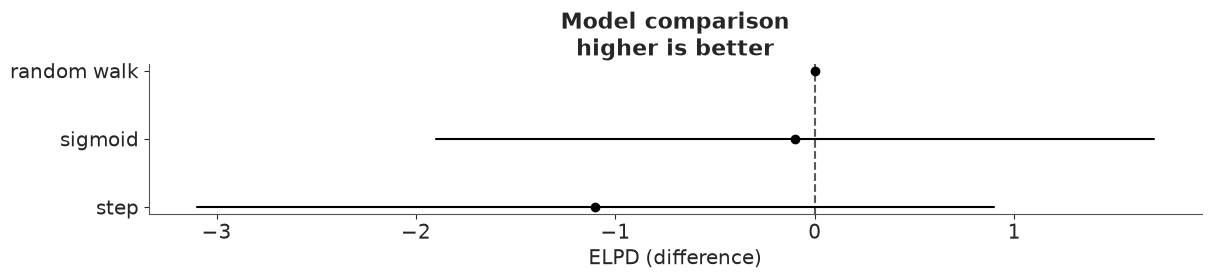

In [23]:
az.plot_compare(comparison);

The three `elpd` values differ by about one unit, with standard errors of the differences
(`dse`) around two. **The data cannot tell an abrupt change from a gradual one**, nor from
a smoothly drifting rate. With one to three events a year there is simply not enough
information in a decade of counts to resolve the *shape* of the decline; what all three
models agree on is its size and its approximate date. The sigmoid's `width` tells the same
story from the inside: its posterior (mean about 3 years) has barely moved from its prior
(mean 4 years).

## 8 · Interpretation

In [24]:
ratio = step_post["early_rate"] / step_post["late_rate"]
print(f"early rate {float(step_post['early_rate'].mean()):.2f}, late rate {float(step_post['late_rate'].mean()):.2f} per year")
print(f"early / late = {float(ratio.mean()):.1f}, 94% HDI {az.hdi(ratio.values, prob=0.94).round(1)}")
print(f"P(switchpoint in 1887-1895) = {p_switch.loc[1887:1895].sum():.2f}")
tau_draws = sigmoid_idata.posterior["tau"]
print(f"sigmoid midpoint tau = {float(tau_draws.mean()):.0f}, 94% HDI {az.hdi(tau_draws, prob=0.94).values.round(0)}")

early rate 3.11, late rate 0.93 per year
early / late = 3.4, 94% HDI [2.4 4.3]
P(switchpoint in 1887-1895) = 0.94
sigmoid midpoint tau = 1891, 94% HDI [1886. 1897.]


Large colliery explosions went from about three a year to just under one a year - a
reduction by a factor of about 3.4 (94% HDI 2.4 to 4.3) - and whichever model we ask places
the change around 1890, give or take about five years.

That window matches the period in which explosion risk was tackled systematically. A Royal
Commission on Accidents in Mines reported in 1886 on firedamp, coal dust, safety lamps and
shot-firing; the Coal Mines Regulation Act of 1887 turned much of that into law, and
regulation of explosives followed in the 1890s. And coal output kept *rising* until 1913,
so the fall in the rate per ton mined is steeper than the fall in the count.

What the model does **not** show is causation. It finds *when* the rate changed, not
*why*, and by construction it looks for exactly one change. The smooth models, which fit
equally well, are compatible with a story of gradual adoption through the late 1880s and
1890s rather than a single decisive Act. The honest summary for a historian: a threefold
improvement, centred on the years just after the 1887 Act, of unknown abruptness.

### Try it yourself

1. **Two changepoints.** Add a second switchpoint (with `s1 < s2`) and a third rate. First
   with `DiscreteUniform` and the compound step - how do ESS and `r_hat` for the two dates
   look now? Then marginalise: the sum runs over pairs, but it is still a `logsumexp`.
   Does LOO support the third regime?
2. **Use the exact dates.** Aggregating to years discards information. Model the *waiting
   times* between disasters (`coal.date.diff()`) as Exponential with a rate that switches,
   and compare the switchpoint posterior with the annual one.
3. **Prior sensitivity of the verdict.** Give the sigmoid `width` a prior that favours slow
   transitions (say `Gamma(4, 0.2)`, mean 20 years). Does LOO now separate it from the
   step model? What does that tell you about how much the data know about `width`?

Next: challenge **C07**, where the latent state is continuous but there is one per day.